In [1]:
!pip install numpy scipy librosa scikit-learn matplotlib soundfile tqdm


  Obtaining dependency information for librosa from https://files.pythonhosted.org/packages/b5/ba/c63c5786dfee4c3417094c4b00966e61e4a63efecee22cb7b4c0387dda83/librosa-0.11.0-py3-none-any.whl.metadata
  Obtaining dependency information for soundfile from https://files.pythonhosted.org/packages/14/e9/6b761de83277f2f02ded7e7ea6f07828ec78e4b229b80e4ca55dd205b9dc/soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata
  Obtaining dependency information for audioread>=2.1.9 from https://files.pythonhosted.org/packages/7e/16/fbe8e1e185a45042f7cd3a282def5bb8d95bb69ab9e9ef6a5368aa17e426/audioread-3.1.0-py3-none-any.whl.metadata
  Obtaining dependency information for pooch>=1.1 from https://files.pythonhosted.org/packages/2a/2d/d4bf65e47cea8ff2c794a600c4fd1273a7902f268757c531e0ee9f18aa58/pooch-1.9.0-py3-none-any.whl.metadata
  Obtaining dependency information for soxr>=0.3.2 from https://files.pythonhosted.org/packages/b5/a7/628479336206959463d08260bffed87905e7ba9e3bd83ca6b405a0736e94/soxr-1.0.0-cp

ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Sanjana\\anaconda3\\Lib\\site-packages\\~-mpy.libs\\libopenblas64__v0.3.23-293-gc2f4bdbb-gcc_10_3_0-2bde3a66a51006b2b53eb373ff767a3f.dll'
Consider using the `--user` option or check the permissions.



In [3]:
!pip install --user numpy scipy librosa scikit-learn matplotlib soundfile tqdm


  Obtaining dependency information for librosa from https://files.pythonhosted.org/packages/b5/ba/c63c5786dfee4c3417094c4b00966e61e4a63efecee22cb7b4c0387dda83/librosa-0.11.0-py3-none-any.whl.metadata
  Using cached librosa-0.11.0-py3-none-any.whl.metadata (8.7 kB)
  Obtaining dependency information for soundfile from https://files.pythonhosted.org/packages/14/e9/6b761de83277f2f02ded7e7ea6f07828ec78e4b229b80e4ca55dd205b9dc/soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata
  Using cached soundfile-0.13.1-py2.py3-none-win_amd64.whl.metadata (16 kB)
  Obtaining dependency information for audioread>=2.1.9 from https://files.pythonhosted.org/packages/7e/16/fbe8e1e185a45042f7cd3a282def5bb8d95bb69ab9e9ef6a5368aa17e426/audioread-3.1.0-py3-none-any.whl.metadata
  Using cached audioread-3.1.0-py3-none-any.whl.metadata (9.0 kB)
  Obtaining dependency information for pooch>=1.1 from https://files.pythonhosted.org/packages/2a/2d/d4bf65e47cea8ff2c794a600c4fd1273a7902f268757c531e0ee9f18aa58/pooch-1

In [1]:
import numpy
import librosa
import sklearn
import matplotlib
import soundfile
print("All imports working ✅")


All imports working ✅


In [3]:
import os

INPUT_DIR = r"C:\Users\Sanjana\OneDrive\Desktop\coding\ALL_ML\Violence_detector\archive\audios_VSD\audios_VSD"
OUTPUT_DIR = r"C:\Users\Sanjana\OneDrive\Desktop\coding\ALL_ML\Violence_detector\data"

os.makedirs(os.path.join(OUTPUT_DIR, "violent"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "non_violent"), exist_ok=True)

print("Folders ready ✅")


Folders ready ✅


In [5]:
import os

DATASET = []

INPUT_DIR = r"C:\Users\Sanjana\OneDrive\Desktop\coding\ALL_ML\Violence_detector\archive\audios_VSD\audios_VSD"

for file in os.listdir(INPUT_DIR):

    if not file.lower().endswith(".wav"):
        continue

    path = os.path.join(INPUT_DIR, file)

    if "noviolence" in file.lower():
        label = 0   # non-violent
    else:
        label = 1   # violent

    DATASET.append((path, label))

print("Total files:", len(DATASET))


Total files: 131


In [6]:
import numpy as np

def adc_quantize(signal, bits=10):
    """
    Simulate ADC quantization
    """
    max_val = np.max(np.abs(signal))
    
    if max_val == 0:
        return signal

    signal_norm = signal / max_val
    levels = 2 ** bits
    
    quantized = np.round(signal_norm * (levels / 2)) / (levels / 2)
    
    return quantized


In [8]:
import librosa

def extract_features(file_path, bits=10):
    
    y, sr = librosa.load(file_path, sr=16000)
    
    # Apply ADC simulation
    y_q = adc_quantize(y, bits)
    
    energy = np.sum(y_q ** 2)
    zcr = np.mean(librosa.feature.zero_crossing_rate(y_q))
    centroid = np.mean(
        librosa.feature.spectral_centroid(y=y_q, sr=sr)
    )
    
    return [energy, zcr, centroid]






In [9]:
X = []
y = []

BITS = 10

for path, label in DATASET:
    
    try:
        feats = extract_features(path, bits=BITS)
        
        X.append(feats)
        y.append(label)
        
    except Exception as e:
        print("Error:", path, e)

print("Feature extraction done ✅")


Feature extraction done ✅


In [10]:
X_aug = []
y_aug = []

for feats, label in zip(X, y):
    
    X_aug.append(feats)
    y_aug.append(label)
    
    if label == 0:   # non-violent
        
        for _ in range(10):
            
            noise = np.random.normal(0, 0.01, len(feats))
            new_feats = feats + noise
            
            X_aug.append(new_feats)
            y_aug.append(label)

print("Augmentation complete ✅")


Augmentation complete ✅


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

X_np = np.array(X_aug)
y_np = np.array(y_aug)

X_train, X_test, y_train, y_test = train_test_split(
    X_np, y_np, test_size=0.3, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Accuracy:", acc)


Accuracy: 0.9038461538461539


In [12]:
test_file = DATASET[0][0]   # try any file path

features = extract_features(test_file, bits=10)
prediction = model.predict([features])[0]

print("Prediction:", "Violence" if prediction == 1 else "Non-Violence")


Prediction: Violence


In [14]:
test_file = DATASET[10][0]

features = extract_features(test_file, bits=10)
prediction = model.predict([features])[0]

print("File:", test_file)
print("Prediction:", "Violence" if prediction == 1 else "Non-Violence")


File: C:\Users\Sanjana\OneDrive\Desktop\coding\ALL_ML\Violence_detector\archive\audios_VSD\audios_VSD\angry_021.wav
Prediction: Violence


In [15]:
def predict_audio(file_path, bits=10):
    
    features = extract_features(file_path, bits=bits)
    prediction = model.predict([features])[0]
    
    label = "Violence" if prediction == 1 else "Non-Violence"
    
    print("File:", file_path)
    print("Prediction:", label)
    
    return label


In [16]:
predict_audio(r"C:\Users\Sanjana\OneDrive\Desktop\coding\ALL_ML\Violence_detector\archive\audios_VSD\audios_VSD\angry_021.wav")

File: C:\Users\Sanjana\OneDrive\Desktop\coding\ALL_ML\Violence_detector\archive\audios_VSD\audios_VSD\angry_021.wav
Prediction: Violence


'Violence'

## Chart 1 — Waveform Before vs After ADC

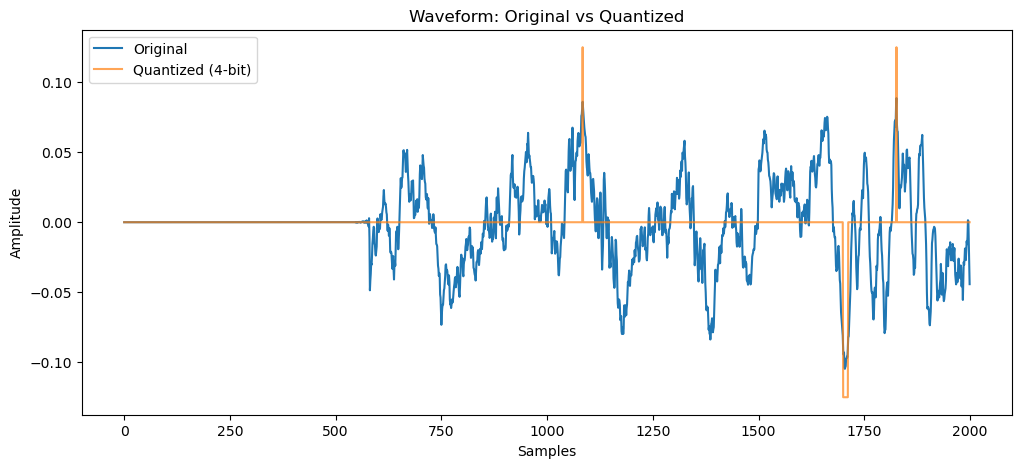

In [17]:
import matplotlib.pyplot as plt
import librosa

file_path = DATASET[0][0]

y, sr = librosa.load(file_path, sr=16000)
y_q = adc_quantize(y, bits=4)

plt.figure(figsize=(12,5))

plt.plot(y[:2000], label="Original")
plt.plot(y_q[:2000], label="Quantized (4-bit)", alpha=0.7)

plt.legend()
plt.title("Waveform: Original vs Quantized")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()


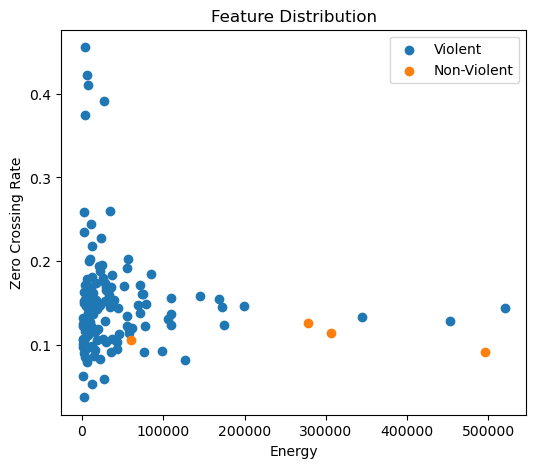

In [18]:
import pandas as pd

data = []

for path, label in DATASET:
    feats = extract_features(path, bits=10)
    data.append(feats + [label])

df = pd.DataFrame(data, columns=["Energy", "ZCR", "Centroid", "Label"])

violent = df[df["Label"] == 1]
nonviolent = df[df["Label"] == 0]

plt.figure(figsize=(6,5))
plt.scatter(violent["Energy"], violent["ZCR"], label="Violent")
plt.scatter(nonviolent["Energy"], nonviolent["ZCR"], label="Non-Violent")

plt.xlabel("Energy")
plt.ylabel("Zero Crossing Rate")
plt.legend()
plt.title("Feature Distribution")
plt.show()


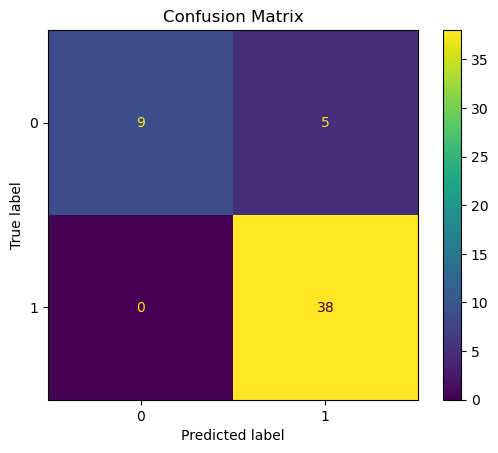

In [19]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()


In [20]:
labels = ["Non-Violent", "Violent"]
counts = [y.count(0), y.count(1)]

plt.bar(labels, counts)
plt.title("Dataset Distribution")
plt.ylabel("Number of Samples")
plt.show()


AttributeError: 'numpy.ndarray' object has no attribute 'count'

In [21]:
import os

INPUT_DIR = r"C:\Users\Sanjana\OneDrive\Desktop\coding\ALL_ML\Violence_detector\archive\audios_VSD\audios_VSD"

files = []

for file in os.listdir(INPUT_DIR):
    if file.lower().endswith(".wav"):
        path = os.path.join(INPUT_DIR, file)
        size = os.path.getsize(path) / (1024 * 1024)  # MB
        files.append((file, size))

files_sorted = sorted(files, key=lambda x: x[1], reverse=True)

for f in files_sorted[:10]:
    print(f)


('noviolence_03.wav', 835.4181976318359)
('noviolence_01.wav', 830.8742523193359)
('noviolence_02.wav', 752.9727306365967)
('noviolence_04.wav', 627.6579437255859)
('angry_20.wav', 261.4883556365967)
('angry_12.wav', 260.2110118865967)
('angry_13.wav', 161.54694938659668)
('angry_15.wav', 133.88288688659668)
('angry_03.wav', 124.91804313659668)
('angry_04.wav', 116.45319938659668)


In [22]:
INPUT_DIR = r"C:\Users\Sanjana\OneDrive\Desktop\coding\ALL_ML\Violence_detector\archive\audios_VSD\audios_VSD"

nonviolent_files = [
    "noviolence_01.wav",
    "noviolence_02.wav",
    "noviolence_03.wav",
    "noviolence_04.wav"
]


In [23]:
import librosa
import soundfile as sf
import os

OUTPUT_DIR = "generated_nonviolent"
os.makedirs(OUTPUT_DIR, exist_ok=True)

SR = 16000
CLIP_DURATION = 3
segment_len = SR * CLIP_DURATION

count = 0

for file in nonviolent_files:

    file_path = os.path.join(INPUT_DIR, file)
    print("Processing:", file)

    y, sr = librosa.load(file_path, sr=SR)

    for start in range(0, len(y), segment_len):

        segment = y[start:start + segment_len]

        if len(segment) < segment_len:
            continue

        save_path = os.path.join(
            OUTPUT_DIR,
            f"nonviolent_{count}.wav"
        )

        sf.write(save_path, segment, SR)
        count += 1

print("Total non-violent clips created:", count)


Processing: noviolence_01.wav
Processing: noviolence_02.wav
Processing: noviolence_03.wav
Processing: noviolence_04.wav
Total non-violent clips created: 6035


In [24]:
import os

INPUT_DIR = r"C:\Users\Sanjana\OneDrive\Desktop\coding\ALL_ML\Violence_detector\archive\audios_VSD\audios_VSD"

large_violent = []

for file in os.listdir(INPUT_DIR):
    
    if not file.lower().endswith(".wav"):
        continue
        
    if "noviolence" in file.lower():
        continue
    
    size = os.path.getsize(os.path.join(INPUT_DIR, file)) / (1024*1024)
    
    if size > 100:   # >100MB considered large
        large_violent.append(file)

print(large_violent)


['angry_01.wav', 'angry_03.wav', 'angry_04.wav', 'angry_07.wav', 'angry_08.wav', 'angry_09.wav', 'angry_10.wav', 'angry_12.wav', 'angry_13.wav', 'angry_14.wav', 'angry_15.wav', 'angry_20.wav']


In [25]:
import librosa
import soundfile as sf

OUTPUT_DIR_V = "generated_violent"
os.makedirs(OUTPUT_DIR_V, exist_ok=True)

SR = 16000
CLIP_DURATION = 3
segment_len = SR * CLIP_DURATION

count = 0

for file in large_violent:
    
    file_path = os.path.join(INPUT_DIR, file)
    print("Processing:", file)
    
    y, sr = librosa.load(file_path, sr=SR)
    
    for start in range(0, len(y), segment_len):
        
        segment = y[start:start + segment_len]
        
        if len(segment) < segment_len:
            continue
        
        save_path = os.path.join(
            OUTPUT_DIR_V,
            f"violent_{count}.wav"
        )
        
        sf.write(save_path, segment, SR)
        count += 1

print("Generated violent clips:", count)


Processing: angry_01.wav
Processing: angry_03.wav
Processing: angry_04.wav
Processing: angry_07.wav
Processing: angry_08.wav
Processing: angry_09.wav
Processing: angry_10.wav
Processing: angry_12.wav
Processing: angry_13.wav
Processing: angry_14.wav
Processing: angry_15.wav
Processing: angry_20.wav
Generated violent clips: 3359


In [26]:
import os
import random
import shutil

violent_src = "generated_violent"
nonviolent_src = "generated_nonviolent"

violent_dst = "selected_violent"
nonviolent_dst = "selected_nonviolent"

os.makedirs(violent_dst, exist_ok=True)
os.makedirs(nonviolent_dst, exist_ok=True)

N = 300   # number per class

# select violent
violent_files = random.sample(os.listdir(violent_src), N)

for f in violent_files:
    shutil.copy(
        os.path.join(violent_src, f),
        os.path.join(violent_dst, f)
    )

# select non-violent
nonviolent_files = random.sample(os.listdir(nonviolent_src), N)

for f in nonviolent_files:
    shutil.copy(
        os.path.join(nonviolent_src, f),
        os.path.join(nonviolent_dst, f)
    )

print("Balanced dataset created ✅")


Balanced dataset created ✅


In [27]:
DATASET = []

for file in os.listdir("selected_violent"):
    DATASET.append((os.path.join("selected_violent", file), 1))

for file in os.listdir("selected_nonviolent"):
    DATASET.append((os.path.join("selected_nonviolent", file), 0))

print("Dataset size:", len(DATASET))


Dataset size: 600


In [28]:
import numpy as np
import librosa

def adc_quantize(signal, bits=10):
    
    max_val = np.max(np.abs(signal))
    
    if max_val == 0:
        return signal
    
    signal_norm = signal / max_val
    levels = 2 ** bits
    
    quantized = np.round(signal_norm * (levels / 2)) / (levels / 2)
    
    return quantized


def extract_features(file_path, bits=10):
    
    y, sr = librosa.load(file_path, sr=16000)
    
    y_q = adc_quantize(y, bits)
    
    energy = np.sum(y_q ** 2)
    zcr = np.mean(librosa.feature.zero_crossing_rate(y_q))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y_q, sr=sr))
    
    return [energy, zcr, centroid]


In [29]:
import os

DATASET = []

violent_dir = "selected_violent"
nonviolent_dir = "selected_nonviolent"

for file in os.listdir(violent_dir):
    path = os.path.join(violent_dir, file)
    DATASET.append((path, 1))

for file in os.listdir(nonviolent_dir):
    path = os.path.join(nonviolent_dir, file)
    DATASET.append((path, 0))

print("Dataset size:", len(DATASET))


Dataset size: 600


In [30]:
X = []
y = []

BITS = 10

for path, label in DATASET:
    
    try:
        feats = extract_features(path, bits=BITS)
        X.append(feats)
        y.append(label)
        
    except Exception as e:
        print("Error:", path, e)

print("Feature extraction complete ✅")


Feature extraction complete ✅


In [31]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Model Accuracy:", acc)


Model Accuracy: 0.7388888888888889


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score


In [33]:
models = {
    "Logistic Regression": LogisticRegression(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}


In [34]:
results = {}

for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print(f"{name}: {acc:.3f}")


Logistic Regression: 0.739
SVM: 0.700
Random Forest: 0.722
KNN: 0.739
Gradient Boosting: 0.717


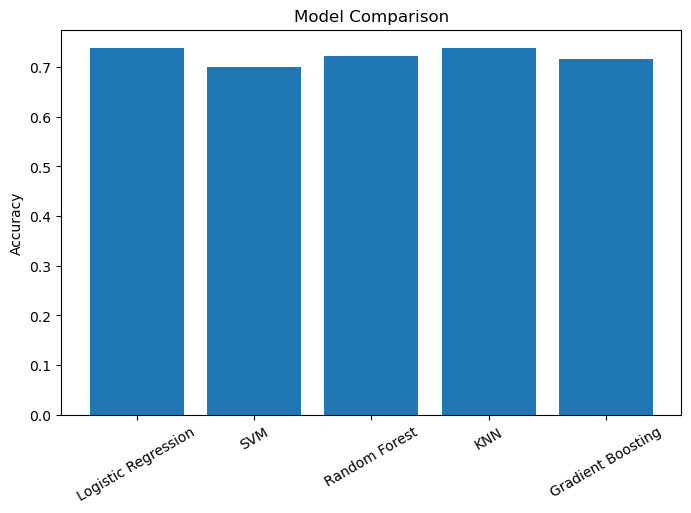

In [35]:
import matplotlib.pyplot as plt

names = list(results.keys())
scores = list(results.values())

plt.figure(figsize=(8,5))
plt.bar(names, scores)

plt.ylabel("Accuracy")
plt.title("Model Comparison")

plt.xticks(rotation=30)
plt.show()


In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import numpy as np

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Final Logistic Regression Accuracy:", acc)


Final Logistic Regression Accuracy: 0.7388888888888889


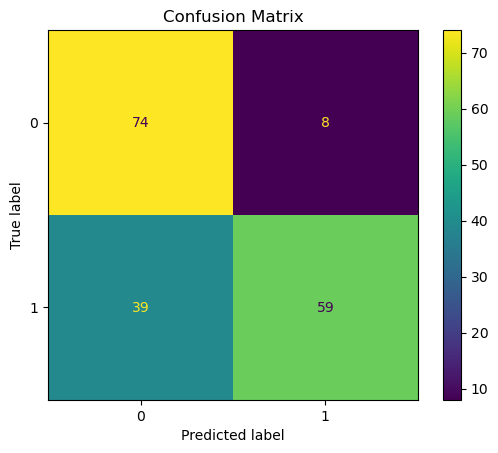

In [37]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix")
plt.show()


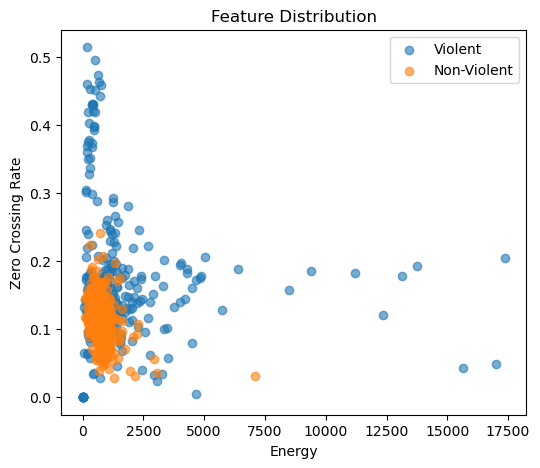

In [38]:
import pandas as pd

df = pd.DataFrame(X, columns=["Energy", "ZCR", "Centroid"])
df["Label"] = y

violent = df[df["Label"] == 1]
nonviolent = df[df["Label"] == 0]

plt.figure(figsize=(6,5))

plt.scatter(violent["Energy"], violent["ZCR"], label="Violent", alpha=0.6)
plt.scatter(nonviolent["Energy"], nonviolent["ZCR"], label="Non-Violent", alpha=0.6)

plt.xlabel("Energy")
plt.ylabel("Zero Crossing Rate")
plt.legend()
plt.title("Feature Distribution")
plt.show()


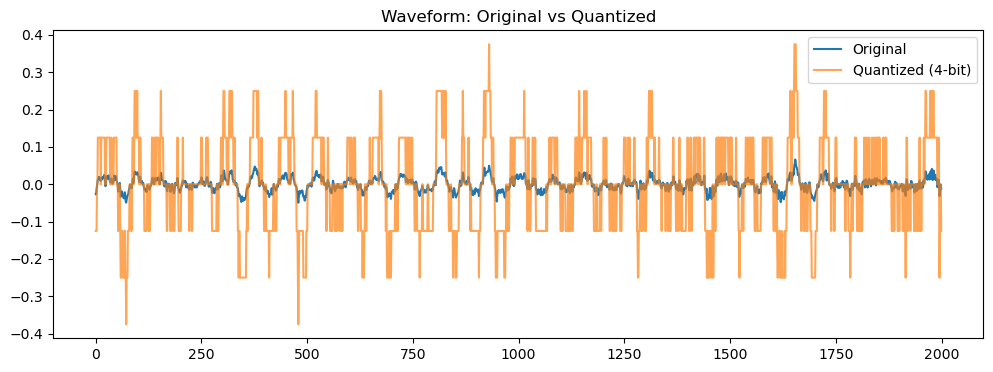

In [39]:
import random

sample_file = random.choice(DATASET)[0]

y_audio, sr = librosa.load(sample_file, sr=16000)
y_q = adc_quantize(y_audio, bits=4)

plt.figure(figsize=(12,4))

plt.plot(y_audio[:2000], label="Original")
plt.plot(y_q[:2000], label="Quantized (4-bit)", alpha=0.7)

plt.legend()
plt.title("Waveform: Original vs Quantized")
plt.show()


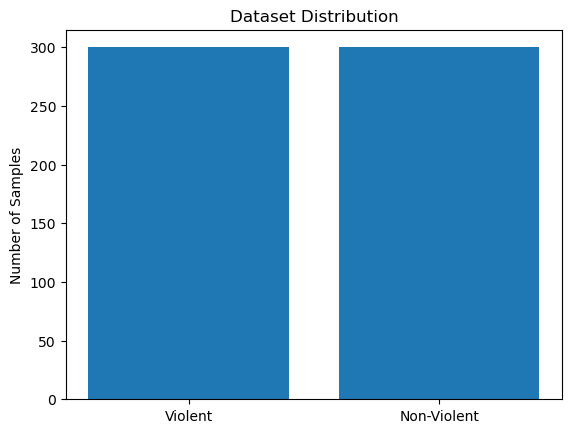

In [40]:
violent_count = sum(1 for _, label in DATASET if label == 1)
nonviolent_count = sum(1 for _, label in DATASET if label == 0)

plt.bar(["Violent", "Non-Violent"], [violent_count, nonviolent_count])
plt.title("Dataset Distribution")
plt.ylabel("Number of Samples")
plt.show()


In [41]:
from IPython.display import Audio
import random

def predict_audio(file_path):
    
    print("File:", file_path)
    display(Audio(file_path))
    
    features = extract_features(file_path, bits=10)
    prediction = model.predict([features])[0]
    
    label = "Violence" if prediction == 1 else "Non-Violence"
    
    print("Prediction:", label)
    print("-" * 40)


# test 5 random samples
for _ in range(5):
    file_path, true_label = random.choice(DATASET)
    
    print("Actual:", "Violence" if true_label == 1 else "Non-Violence")
    predict_audio(file_path)


Actual: Violence
File: selected_violent\violent_3137.wav


Prediction: Violence
----------------------------------------
Actual: Non-Violence
File: selected_nonviolent\nonviolent_4742.wav


Prediction: Non-Violence
----------------------------------------
Actual: Non-Violence
File: selected_nonviolent\nonviolent_912.wav


Prediction: Violence
----------------------------------------
Actual: Non-Violence
File: selected_nonviolent\nonviolent_3337.wav


Prediction: Non-Violence
----------------------------------------
Actual: Violence
File: selected_violent\violent_1935.wav


Prediction: Non-Violence
----------------------------------------


## improving accuracy

In [43]:
import numpy as np
import librosa

def extract_features(file_path, bits=10):
    
    y, sr = librosa.load(file_path, sr=16000)
    y_q = adc_quantize(y, bits)
    
    # Basic features
    energy = np.sum(y_q ** 2)
    zcr = np.mean(librosa.feature.zero_crossing_rate(y_q))
    centroid = np.mean(librosa.feature.spectral_centroid(y=y_q, sr=sr))
    
    # MFCC features (important)
    mfcc = librosa.feature.mfcc(y=y_q, sr=sr, n_mfcc=13)
    mfcc_mean = np.mean(mfcc, axis=1)
    
    features = [energy, zcr, centroid]
    features.extend(mfcc_mean)
    
    return features


In [44]:
X = []
y = []

for path, label in DATASET:
    
    try:
        feats = extract_features(path, bits=10)
        X.append(feats)
        y.append(label)
        
    except Exception as e:
        print("Error:", path, e)

print("Feature extraction complete")


Feature extraction complete


In [45]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

X = np.array(X)
y = np.array(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model = LogisticRegression(
    max_iter=2000,
    C=1.0,
    solver="lbfgs"
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

acc = accuracy_score(y_test, y_pred)

print("Improved Accuracy:", acc)


Improved Accuracy: 0.9


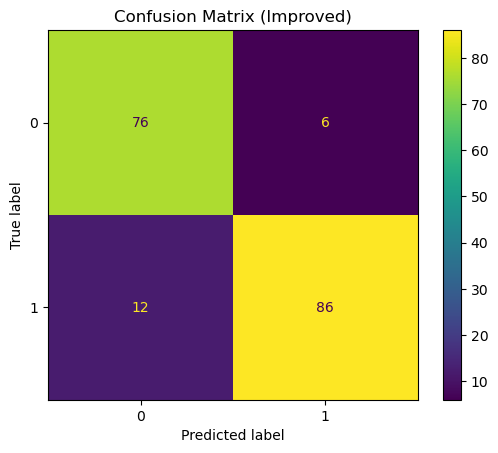

In [47]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.title("Confusion Matrix (Improved)")
plt.show()


In [48]:
from IPython.display import Audio, display
import random

def predict_audio(file_path):
    
    print("File:", file_path)
    display(Audio(file_path))
    
    features = extract_features(file_path, bits=10)
    features = scaler.transform([features])
    
    prediction = model.predict(features)[0]
    prob = model.predict_proba(features)[0]
    
    label = "Violence" if prediction == 1 else "Non-Violence"
    
    print("Prediction:", label)
    print("Violence Probability:", prob[1])
    print("Non-Violence Probability:", prob[0])
    print("-" * 40)


# Test 5 random files
for _ in range(5):
    file_path, true_label = random.choice(DATASET)
    
    print("Actual:", "Violence" if true_label == 1 else "Non-Violence")
    predict_audio(file_path)


Actual: Non-Violence
File: selected_nonviolent\nonviolent_3816.wav


Prediction: Non-Violence
Violence Probability: 0.14219165618233778
Non-Violence Probability: 0.8578083438176622
----------------------------------------
Actual: Violence
File: selected_violent\violent_1201.wav


Prediction: Violence
Violence Probability: 0.8405692069118139
Non-Violence Probability: 0.15943079308818608
----------------------------------------
Actual: Violence
File: selected_violent\violent_1750.wav


Prediction: Violence
Violence Probability: 0.8824183990151521
Non-Violence Probability: 0.11758160098484793
----------------------------------------
Actual: Non-Violence
File: selected_nonviolent\nonviolent_4441.wav


Prediction: Non-Violence
Violence Probability: 0.4080711801889249
Non-Violence Probability: 0.591928819811075
----------------------------------------
Actual: Violence
File: selected_violent\violent_843.wav


Prediction: Violence
Violence Probability: 0.9901927937385202
Non-Violence Probability: 0.009807206261479795
----------------------------------------


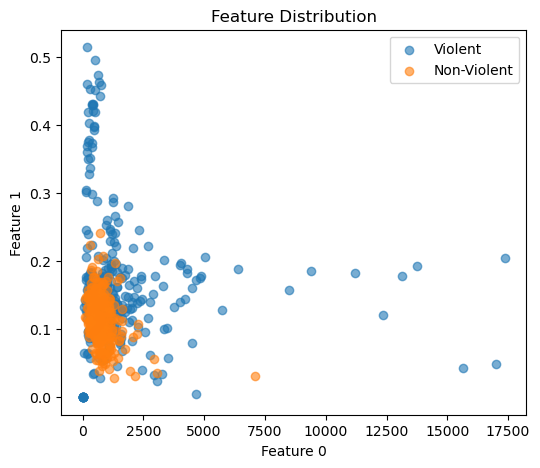

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(X, columns=[f"F{i}" for i in range(X.shape[1])])
df["Label"] = y

violent = df[df["Label"] == 1]
nonviolent = df[df["Label"] == 0]

plt.figure(figsize=(6,5))

plt.scatter(violent["F0"], violent["F1"], label="Violent", alpha=0.6)
plt.scatter(nonviolent["F0"], nonviolent["F1"], label="Non-Violent", alpha=0.6)

plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend()
plt.title("Feature Distribution")
plt.show()


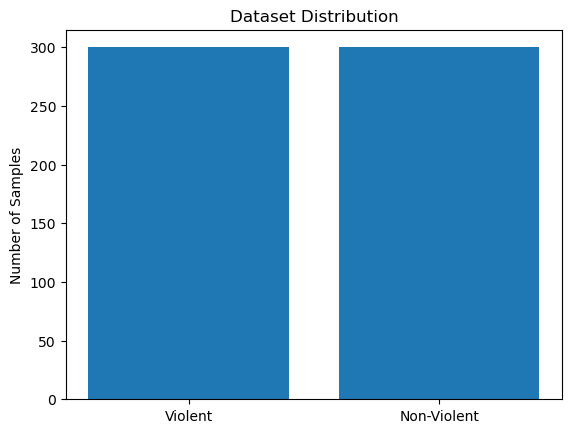

In [50]:
violent_count = sum(1 for _, label in DATASET if label == 1)
nonviolent_count = sum(1 for _, label in DATASET if label == 0)

plt.bar(["Violent", "Non-Violent"], [violent_count, nonviolent_count])
plt.title("Dataset Distribution")
plt.ylabel("Number of Samples")
plt.show()


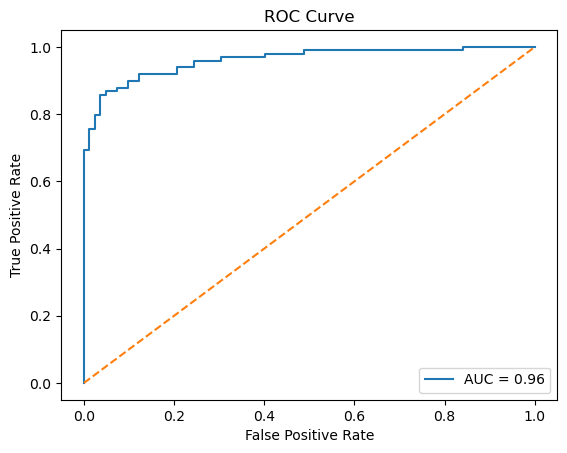

In [51]:
from sklearn.metrics import roc_curve, auc

y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


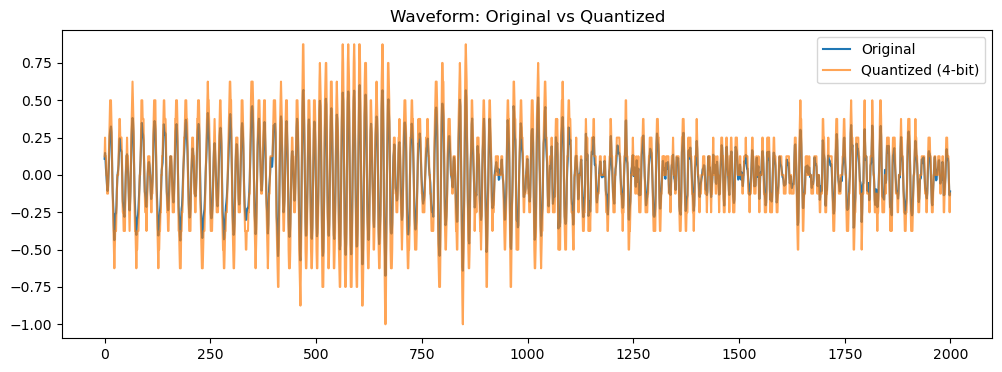

In [52]:
import random

sample_file = random.choice(DATASET)[0]

y_audio, sr = librosa.load(sample_file, sr=16000)
y_q = adc_quantize(y_audio, bits=4)

plt.figure(figsize=(12,4))

plt.plot(y_audio[:2000], label="Original")
plt.plot(y_q[:2000], label="Quantized (4-bit)", alpha=0.7)

plt.legend()
plt.title("Waveform: Original vs Quantized")
plt.show()


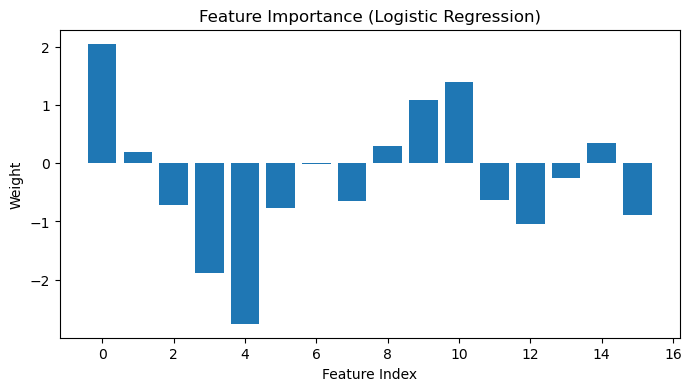

In [53]:
importance = model.coef_[0]

plt.figure(figsize=(8,4))
plt.bar(range(len(importance)), importance)

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Feature Index")
plt.ylabel("Weight")
plt.show()


In [54]:
import joblib

joblib.dump(model, "violence_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Saved successfully")


Saved successfully


In [1]:
import joblib
from sklearn.linear_model import LogisticRegression

# load your prepared data
# assuming X_train, y_train, scaler already exist
# if not, rebuild quickly

model = LogisticRegression(
    max_iter=2000,
    C=1.0,
    solver="lbfgs"
)

model.fit(X_train, y_train)

joblib.dump(model, "violence_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully")


NameError: name 'X_train' is not defined